# Time Series Forecasting Benchmark
### Foundation Models vs. AutoML vs. Modern Tabular ML

**Dataset:** Walmart Weekly Sales (Multi-Series - 7 Store Departments)  
**Forecast Horizon (H):** 5 weeks  
**Validation Protocol:** Strict Out-of-Time Split (last 5 historical timestamps held out as test)

---

## Executive Summary & Methodological Roadmap

This notebook delivers an **industrial-grade multi-series forecasting benchmark**.  
We compare five distinct modelling paradigms under identical data conditions and evaluation metrics (WAPE, MAE, RMSE, R-squared).

### PART 1 - Methodological EDA & Signal Processing
- Data profiling, cleaning and distribution-drift analysis (Train vs Test)
- Spectral density estimation (Welch PSD) and STL seasonality decomposition
- Grouped Partial Autocorrelation (PACF) with theoretical significance bounds (+/- 2/sqrt(N))

### PART 2 - Feature Engineering Suite & Information-Gain Audit
- Automated Fourier harmonics + calendar signatures
- Modular Scikit-Learn transformers (Flagnan3, Flagout2, TargetEncoderFastPandas2, ...)
- Mutual-information / Pearson / Spearman diagnostics

### PART 3 - Multi-Paradigm Forecasting Tournament
| # | Contender | Paradigm |
|---|-----------|----------|
| 1 | skforecast | Local recursive LightGBM + rolling features |
| 2 | Manual recursive loop | Explicit step-by-step autoregression (feature-engine) |
| 3 | mlforecast | Global high-speed LightGBM (Numba engine) |
| 4 | Google TimesFM 500M | Zero-shot Transformer foundation model |
| 5 | AutoGluon-TimeSeries | AutoML weighted ensemble (Chronos + DL + GBDTs) |


## 0. Environment Setup


In [1]:
# Core dependency installation (run once)
!pip install -q pytimetk==2.4.1
!pip install -q skforecast mlforecast autogluon.timeseries optuna skrub
!pip install feature-engine --no-deps
!pip install -q timesfm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.8/233.8 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 33.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.7/529.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.4/274.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.7/90.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.4/248.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 7.3 MB/s eta 0:00:00
 

## 1. Imports & Global Configuration


In [3]:
# -*- coding: utf-8 -*-
import os
import time
import warnings
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.signal import welch
from scipy import stats
from statsmodels.tsa.stattools import pacf, adfuller
from tabulate import tabulate

# Pipeline & modelling
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor

# Custom transformers (user-developed modular framework)
from pandas_transformers import (
    categorizar_todo_pandas,
    add_time_features_pandas,
    Flagnan3,
    Flagout2,
    RareLabelPandas,
    TargetEncoderFastPandas2,
    BiniPandas2,
    PercentileRankerPandas2,
    ZeroInflatedTransformerPandas2,
)
from dashboards2 import (
    classify_variables,
    fast_eda_report,
    compute_feature_diagnostics,
    audit_fe_information_gain,
)
from loaders import skim, clean_dataframe

# Feature-engine
from feature_engine.discretisation import EqualFrequencyDiscretiser, EqualWidthDiscretiser
from feature_engine.encoding import RareLabelEncoder, OrdinalEncoder, MeanEncoder
from feature_engine.encoding import OneHotEncoder as OneHotEncoder_f
from feature_engine.imputation import AddMissingIndicator, MeanMedianImputer, CategoricalImputer
from feature_engine.outliers import Winsorizer
from feature_engine.selection import DropDuplicateFeatures, DropConstantFeatures, DropFeatures
from feature_engine.transformation import LogTransformer, YeoJohnsonTransformer
from feature_engine.wrappers import SklearnTransformerWrapper
from feature_engine.timeseries.forecasting import LagFeatures, ExpandingWindowFeatures

# Scikit-learn utilities
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import (
    LabelBinarizer, OneHotEncoder, MinMaxScaler, StandardScaler,
    RobustScaler, PolynomialFeatures, LabelEncoder, MultiLabelBinarizer,
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV,
)
from sklearn import set_config
import lightgbm as lgb
import skrub
import pytimetk as tk

# Styling
warnings.filterwarnings("ignore")
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
plt.rcParams["figure.titlesize"] = 14
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

print("All modules, custom transformers and diagnostic suites loaded successfully.")


All modules, custom transformers and diagnostic suites loaded successfully.


In [4]:
def calculate_wape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Weighted Absolute Percentage Error (WAPE)."""
    return float(np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100)


## 2. Data Ingestion & Strict Out-of-Time Split

We load the classic Walmart weekly-sales multi-series, drop leakage-prone columns,  
and reserve the **last 5 weeks of every department** as a pure out-of-time test set.


In [5]:
# Ingestion
raw_df = tk.load_dataset("walmart_sales_weekly", parse_dates=["Date"])

# Variable configuration
target = "Weekly_Sales"
date_col = "Date"
group_cols = ["Dept"]
freq = "W-FRI"          # weekly, Friday-ending
HORIZON = 5

# Drop irrelevant / zero-variance / leakage-prone attributes
clean_df = raw_df.drop(
    columns=[
        "id", "Store", "Type", "Size",
        "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
        "Unemployment",
    ],
    errors="ignore",
)

df = (
    clean_df[group_cols + [date_col, "IsHoliday", target]]
    .sort_values(group_cols + [date_col])
    .reset_index(drop=True)
)
df[date_col] = pd.to_datetime(df[date_col])

# Strict out-of-time partition (last HORIZON weeks per department)
test_df = df.groupby(group_cols).tail(HORIZON).copy()
train_df = df.drop(test_df.index).copy()

print(f"Total rows          : {df.shape[0]:,} across {df['Dept'].nunique()} departments")
print(f"Training records    : {train_df.shape[0]:,} "
      f"({train_df[date_col].min().strftime('%Y-%m-%d')} -> {train_df[date_col].max().strftime('%Y-%m-%d')})")
print(f"Test records        : {test_df.shape[0]:,} "
      f"({HORIZON} steps/dept: {test_df[date_col].min().strftime('%Y-%m-%d')} -> "
      f"{test_df[date_col].max().strftime('%Y-%m-%d')})")

# Continuity check: every department must have a complete weekly grid
n_steps = len(pd.date_range(start=df.Date.min(), end=df.Date.max(), freq=freq))
n_group = df.Dept.nunique()
assert n_steps * n_group == df.shape[0], "Missing dates detected - lag features would be invalid"

# Temporary type flag for visualisation
train_df["type"] = "train"
test_df["type"] = "test"
df_viz = pd.concat([train_df, test_df])
train_df = train_df.drop(columns="type")
test_df = test_df.drop(columns="type")
df_viz.head()


Total rows          : 1,001 across 7 departments
Training records    : 966 (2010-02-05 -> 2012-09-21)
Test records        : 35 (5 steps/dept: 2012-09-28 -> 2012-10-26)


,Dept,Date,IsHoliday,Weekly_Sales,type
0,1,2010-02-05,False,24924.50,train
1,1,2010-02-12,True,46039.49,train
2,1,2010-02-19,False,41595.55,train
3,1,2010-02-26,False,19403.54,train
4,1,2010-03-05,False,21827.90,train


### 2.1 Interactive Time-Series Overview


In [6]:
df_viz.groupby("Dept").plot_timeseries(
    date_column="Date",
    value_column="Weekly_Sales",
    color_column="type",
    smooth=False,
    smooth_alpha=0,
    facet_scales="free",
    y_intercept_color=tk.palette_timetk()["steel_blue"],
    width=800,
    height=600,
    engine="plotly",
    plotly_dropdown=True,
)


### 2.2 Distribution Drift Audit (Train vs Test)

A Kolmogorov-Smirnov test on the target confirms whether the hold-out window  
is statistically compatible with the training distribution.


In [7]:
def detect_drift(reference, current, numerical_threshold=0.05, categorical_threshold=0.05):
    """Detect drift in numeric (KS) and categorical (Chi-squared) features."""
    results = {}
    all_cols = set(reference.columns).intersection(set(current.columns))
    for col in all_cols:
        if pd.api.types.is_numeric_dtype(reference[col]):
            stat, p_value = stats.ks_2samp(
                reference[col].dropna(), current[col].dropna()
            )
            results[col] = {
                "type": "numeric",
                "statistic": stat,
                "p_value": p_value,
                "drift": p_value < numerical_threshold,
            }
        else:
            ref_counts = reference[col].value_counts()
            cur_counts = current[col].value_counts()
            all_cats = set(ref_counts.index).union(set(cur_counts.index))
            ref_aligned = ref_counts.reindex(all_cats, fill_value=0)
            cur_aligned = cur_counts.reindex(all_cats, fill_value=0)
            stat, p_value, _, _ = stats.chi2_contingency([ref_aligned, cur_aligned])
            results[col] = {
                "type": "categorical",
                "statistic": stat,
                "p_value": p_value,
                "drift": p_value < categorical_threshold,
            }
    return results


def drift_summary(reference, current):
    """Print a concise drift report."""
    results = detect_drift(reference, current)
    df_drift = pd.DataFrame(results).T
    drifted = df_drift[df_drift["drift"] == True]
    print(f"Total features examined : {len(df_drift)}")
    print(f"Features with drift     : {len(drifted)}")
    if not drifted.empty:
        print("\nDrifted features:")
        for feat in drifted.index:
            print(
                f"  - {feat}  "
                f"(stat={drifted.loc[feat, 'statistic']:.4f}, "
                f"p={drifted.loc[feat, 'p_value']:.4f})"
            )
    return results, df_drift


print("=== DRIFT SUMMARY (Train vs Test target) ===")
results, drift_df = drift_summary(
    pd.DataFrame(train_df[target]), pd.DataFrame(test_df[target])
)
results


=== DRIFT SUMMARY (Train vs Test target) ===
Total features examined : 1
Features with drift     : 0


{'Weekly_Sales': {'type': 'numeric',
  'statistic': np.float64(0.12318840579710146),
  'p_value': np.float64(0.6392479591776936),
  'drift': np.False_}}

## 3. Spectral Density & Dominant Frequencies (Welch PSD)

Welch's method isolates the strongest periodic components that will later  
guide the choice of Fourier base periods.


In [8]:
def get_dominant_frequencies(
    series: pd.Series, fs: int = 1, n_per_seg: int = 52, top_k: int = 3
) -> pd.DataFrame:
    """Welch PSD -> top-k dominant frequencies and corresponding periods (weeks)."""
    clean = series.dropna().values
    frequencies, power = welch(
        clean,
        fs=fs,
        nperseg=min(len(clean), n_per_seg),
        detrend="linear",
        scaling="spectrum",
    )
    freq_power = {f: p for f, p in zip(frequencies, power)}
    top = sorted(freq_power.items(), key=lambda x: x[1], reverse=True)[:top_k]
    res = pd.DataFrame(top, columns=["Frequency", "Power"])
    res["Period_Weeks"] = np.where(res["Frequency"] > 0, 1 / res["Frequency"], np.nan)
    return res


print("=== DOMINANT SPECTRAL FREQUENCIES BY DEPARTMENT ===")
for gr, df2 in train_df.groupby("Dept"):
    print(f"\nDepartment {gr}")
    display(get_dominant_frequencies(df2["Weekly_Sales"]))


=== DOMINANT SPECTRAL FREQUENCIES BY DEPARTMENT ===

Department 1


,Frequency,Power,Period_Weeks
0,0.115385,2.769412e+07,8.666667
1,0.019231,2.278544e+07,52.000000
2,0.134615,2.161972e+07,7.428571



Department 3


,Frequency,Power,Period_Weeks
0,0.038462,2.842483e+07,26.000000
1,0.057692,2.434725e+07,17.333333
2,0.076923,1.553493e+07,13.000000



Department 8


...

,Frequency,Power,Period_Weeks
0,0.230769,3.722823e+07,4.333333
1,0.461538,1.936318e+07,2.166667
2,0.250000,1.305807e+07,4.000000



Department 93


,Frequency,Power,Period_Weeks
0,0.230769,3.203875e+07,4.333333
1,0.250000,1.359387e+07,4.000000
2,0.211538,1.208358e+07,4.727273



Department 95


,Frequency,Power,Period_Weeks
0,0.019231,4.237882e+07,52.000000
1,0.230769,2.147298e+07,4.333333
2,0.000000,1.802790e+07,NaN


## 4. Multi-Series Partial Autocorrelation (PACF)

We compute PACF for every department and overlay the theoretical 95 percent  
significance band +/- 2/sqrt(N). Significant lags become candidates for  
the lag-feature set (always respecting the leakage-free bound Lag >= H).


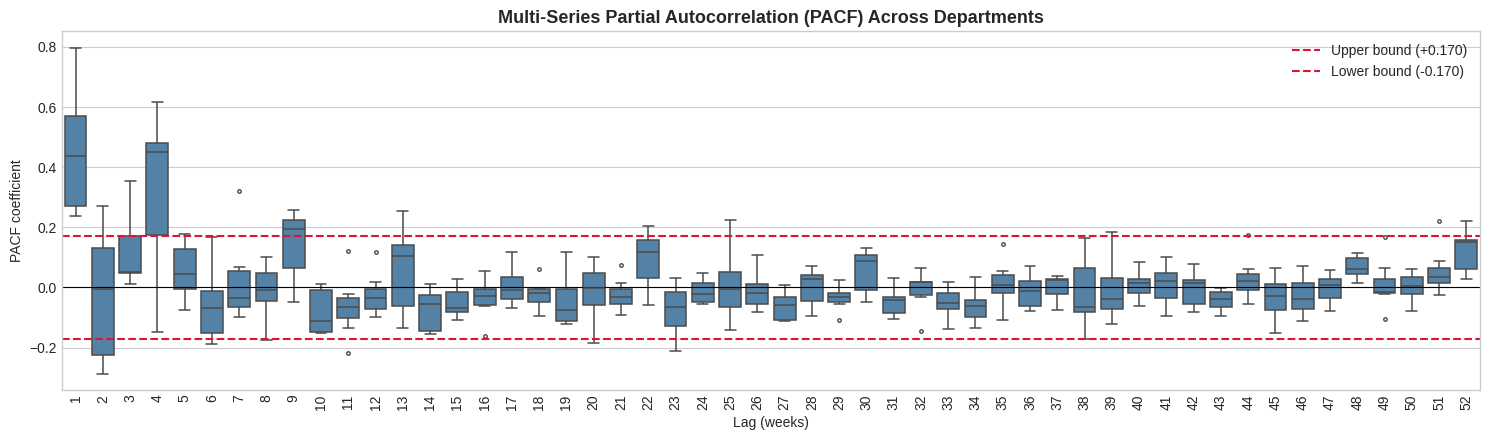

In [9]:
def plot_multi_series_pacf(
    df_in: pd.DataFrame,
    group_col: str,
    date_c: str,
    value_c: str,
    max_lags: int = 52,
):
    """PACF distribution across groups with global significance bounds."""
    records, sample_sizes = [], []
    for gid, gdata in df_in.groupby(group_col):
        s = gdata.sort_values(date_c)[value_c].dropna()
        n = len(s)
        if n > max_lags:
            pacf_vals = pacf(s, nlags=max_lags, method="ywmle")
            sample_sizes.append(n)
            conf = 2 / np.sqrt(n)
            for lag in range(1, max_lags + 1):
                records.append(
                    {
                        "Group": gid,
                        "Lag": lag,
                        "PACF": pacf_vals[lag],
                        "Significant": abs(pacf_vals[lag]) > conf,
                    }
                )
    df_pacf = pd.DataFrame(records)
    global_conf = 2 / np.sqrt(np.median(sample_sizes))

    plt.figure(figsize=(15, 4.5))
    sns.boxplot(
        data=df_pacf, x="Lag", y="PACF", color="steelblue", fliersize=2.5, linewidth=1.1
    )
    plt.axhline(0, color="black", linewidth=0.8)
    plt.axhline(
        global_conf, color="crimson", linestyle="--", linewidth=1.5,
        label=f"Upper bound (+{global_conf:.3f})",
    )
    plt.axhline(
        -global_conf, color="crimson", linestyle="--", linewidth=1.5,
        label=f"Lower bound (-{global_conf:.3f})",
    )
    plt.title(
        "Multi-Series Partial Autocorrelation (PACF) Across Departments",
        fontsize=13, fontweight="bold",
    )
    plt.xlabel("Lag (weeks)")
    plt.ylabel("PACF coefficient")
    plt.xticks(rotation=90)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


plot_multi_series_pacf(train_df, "Dept", date_col, target, max_lags=52)


### Diagnostic Insights - Spectral Density & PACF

**1. Spectral Density (Welch PSD)**  
- **Annual harmonic** (P=52 weeks) dominates most departments (f approx 0.01923).  
- Secondary peaks appear at the **semi-annual** (P=26) and **monthly** (P approx 4.33) cycles.  
- Implication: a single calendar feature (e.g. Month) is insufficient; we therefore construct  
  K pairs of Fourier sine/cosine terms for each of these base periods.

**2. Autocorrelation structure**  
- Lag 1 is strongly significant across all series (median PACF 0.40-0.80).  
- Lag 4 (monthly) and Lag 9 (multi-month replenishment) also exceed the +/-0.17 band.  
- Lag 52 retains year-over-year memory.  
- Because the forecast horizon is H=5, any **direct** lag feature must start at  
  Lag >= 5 to avoid target leakage during multi-step inference.
- For recursive models you may use shorter lags (Lag 1, 4, …). At prediction time the model’s own forecasts are fed back as inputs; this avoids leakage but can cause error accumulation if the one-step predictions are inaccurate.


## 5. STL Decomposition - Irregular Cyclicity vs. Rigid Seasonality

Classic LOESS-based seasonal-trend decomposition reveals why a purely additive,  
fixed-period seasonal component is inadequate for retail demand.


In [10]:
for gr, df2 in train_df.groupby("Dept"):
    print("=" * 90)
    print(f"Department {gr}")
    print("=" * 90)
    stl_fig = tk.plot_stl_diagnostics(
        data=df2,
        date_column="Date",
        value_column="Weekly_Sales",
        facet_ncols=3,
        plotly_dropdown=False,
    )
    stl_fig.show()


Department 1


Department 3


Department 8


Department 13


Department 38


Department 93


Department 95


### Diagnostic Analysis: Irregular Cyclicity vs. Rigid Seasonality  
### & Justification for Fourier Features

A deep inspection of the STL components shows that the demand signal is governed by  
**irregular, non-stationary cycles** rather than a purely deterministic, fixed seasonality:

1. **Irregular cyclical dynamics in `seasadj`**  
   - The seasonally-adjusted series (`seasadj`) still exhibits persistent, time-varying cycles  
     and abrupt volume shifts that standard LOESS filtering fails to isolate.  
   - Rigid seasonal decomposition assumes constant period and amplitude across years;  
     retail demand, however, displays **variable cycle lengths** driven by shifting  
     promotional calendars and **macroeconomic factors**.

2. **Why Fourier features outperform standard decomposition**  
   - **Multi-frequency trigonometric encoding**  
     Incorporating Fourier harmonics  
     sin(2 pi k t / P) and cos(2 pi k t / P)  
     for several base periods P in {52, 26, 4.33} lets non-linear models  
     (e.g. LightGBM) dynamically weight harmonic orders k and adapt to irregular cycle shapes.  
   - **Phase & amplitude flexibility**  
     Unlike fixed STL seasonal indices, Fourier terms give trees continuous,  
     phase-flexible representations of sub-annual demand fluctuations.

3. **Feature-engineering strategy (PART 2)**  
   We replace rigid STL inputs with a hybrid feature space that combines  
   - **Fourier spectral harmonics**,  
   - **time-signature attributes** (week-of-year, month, quarter),  
   - **explicit holiday indicator flags**.


### 5.1 Interactive ACF Diagnostics


In [11]:
fig_dropdown = train_df.groupby("Dept").plot_acf_diagnostics(
    date_column="Date",
    value_column="Weekly_Sales",
    lags=80,
    plotly_dropdown=True,
    height=700,
)
fig_dropdown


## 6. Forecast Evaluation Utilities

Reusable three-panel diagnostics:  
(1) test-horizon zoom, (2) full historical context, (3) actual-vs-predicted bias scatter.


In [12]:
def plot_forecast_evaluation(
    y_train: pd.Series, y_test: pd.Series, y_pred: pd.Series
) -> plt.Figure:
    """Three-panel evaluation plot for a single series."""
    fig, axs = plt.subplots(3, 1, figsize=(14, 16))
    plt.suptitle("Comprehensive Forecast Performance Evaluation", fontsize=16, y=1.01)

    # 1. Test-horizon zoom
    axs[0].plot(y_test, "b-", label="Actual (Test)", alpha=0.8)
    axs[0].plot(y_pred, "r--", label="Prediction")
    axs[0].set_title("1. Test Horizon Zoom")
    axs[0].legend(loc="best")
    axs[0].grid(True)

    # 2. Full context
    axs[1].plot(y_train, color="gray", label="Train (History)", alpha=0.7)
    axs[1].plot(y_test, "b-", label="Actual (Test)")
    axs[1].plot(y_pred, "r--", label="Prediction")
    axs[1].set_title("2. Full Time-Series Context")
    axs[1].legend(loc="best")
    axs[1].grid(True)

    # 3. Bias scatter
    axs[2].scatter(y_test, y_pred, alpha=0.6, color="darkblue")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axs[2].plot(lims, lims, "r--", label="Ideal identity (Y = Yhat)")
    axs[2].set_title("3. Actual vs Predicted (Bias Diagnostic)")
    axs[2].set_xlabel("Actual")
    axs[2].set_ylabel("Predicted")
    axs[2].legend(loc="best")
    axs[2].set_aspect("equal", adjustable="box")
    axs[2].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    return fig


def plot_forecast_evaluation2(
    df_pred: pd.DataFrame,
    train_df: pd.DataFrame,
    target: str = "Weekly_Sales",
    pred_col: str = "pred",
    dept=None,
    date_col: str = "Date",
) -> plt.Figure:
    """Multi-series or aggregated evaluation panel."""
    df_p = df_pred.copy()
    df_t = train_df.copy()
    if date_col in df_p.columns:
        df_p = df_p.set_index(date_col)
    if date_col in df_t.columns:
        df_t = df_t.set_index(date_col)

    if dept is not None:
        y_train = df_t.loc[df_t["Dept"] == dept, target].sort_index()
        df_sub = df_p.loc[df_p["Dept"] == dept].sort_index()
        title_suffix = f" | Dept {dept}"
    else:
        y_train = df_t.groupby(level=date_col)[target].sum().sort_index()
        df_sub = df_p.groupby(level=date_col)[[target, pred_col]].sum().sort_index()
        title_suffix = " | Total Aggregated (All Depts)"

    y_test = df_sub[target]
    y_pred = df_sub[pred_col]

    fig, axs = plt.subplots(3, 1, figsize=(14, 16))
    plt.suptitle(
        f"Comprehensive Forecast Performance Evaluation{title_suffix}",
        fontsize=16, y=1.01,
    )

    axs[0].plot(y_test, "b-", label="Actual (Test)", alpha=0.8)
    axs[0].plot(y_pred, "r--", label="Prediction")
    axs[0].set_title("1. Test Horizon Zoom")
    axs[0].legend(loc="best")
    axs[0].grid(True)

    axs[1].plot(y_train, color="gray", label="Train (History)", alpha=0.7)
    axs[1].plot(y_test, "b-", label="Actual (Test)")
    axs[1].plot(y_pred, "r--", label="Prediction")
    axs[1].set_title("2. Full Time-Series Context")
    axs[1].legend(loc="best")
    axs[1].grid(True)

    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axs[2].scatter(y_test, y_pred, alpha=0.6, color="darkblue")
    axs[2].plot(lims, lims, "r--", label="Ideal reference (Y = Yhat)")
    axs[2].set_title("3. Actual vs Predicted (Bias Assessment)")
    axs[2].set_xlabel("Actual Target")
    axs[2].set_ylabel("Predicted Target")
    axs[2].legend(loc="best")
    axs[2].set_aspect("equal", adjustable="box")
    axs[2].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    return fig


## 7. Feature Engineering - Fourier Harmonics & Time Signatures

Guided by the spectral and STL diagnostics we enrich both train and test  
with Fourier terms for the dominant periods and a rich set of calendar features.


In [13]:
train_df = add_time_features_pandas(
    train_df,
    date_col="Date",
    periods=[1, 4.33, 9, 14, 26, 52],
    max_order=2,
)
test_df = add_time_features_pandas(
    test_df,
    date_col="Date",
    periods=[1, 4.33, 9, 14, 26, 52],
    max_order=2,
)

# Quick profile of the augmented frame
skim(train_df)


── Data Summary ────────────────────────────────────────────────────────────────────────────────────
type       value
-------  -------
Rows         966
Columns       57

Column type frequency:
                  Count
--------------  -------
float32              24
int32                12
uint8                 7
int64                 5
object                4
UInt32                2
float64               1
datetime64[ns]        1
bool                  1


── Variable type: boolean ──────────────────────────────────────────────────────────────────────────
    name         na_count    mean  top_counts
--  ---------  ----------  ------  -----------------------------------
 0  IsHoliday           0  0.0725  False: 896 (92.8%), True: 70 (7.2%)

── Variable type: number ───────────────────────────────────────────────────────────────────────────
    name                 na_count    n_unique        mean         sd         p0        p25         p50         p75        p100  hist
--  -------------

## 8. Multi-Paradigm Forecasting Tournament

We evaluate five architectures under identical conditions:

1. **skforecast** - local sequential autoregressive LightGBM with rolling windows  
2. **Manual recursive loop** - explicit step-by-step inference with feature-engine  
3. **mlforecast** - global Numba-accelerated LightGBM  
4. **Google TimesFM 500M** - zero-shot Transformer foundation model  
5. **AutoGluon-TimeSeries** - AutoML weighted ensemble (Chronos + DL + GBDTs)


### 8.1 Contender A - skforecast (Local Recursive LightGBM)


In [15]:
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures

group_cols = ["Dept"]
target = "Weekly_Sales"
date_col = "Date"
freq = "W-FRI"
use_heavy_pipe = True

t0 = time.time()
all_preds_sk = []
grouped_test = test_df.groupby(group_cols)

print(f"Starting local loop over groups: {group_cols} ...")

for group_val, df_hist in train_df.groupby(group_cols):
    # Retrieve matching test slice
    try:
        df_future = grouped_test.get_group(group_val).sort_values(date_col).copy()
    except KeyError:
        try:
            df_future = grouped_test.get_group(group_val[0]).sort_values(date_col).copy()
        except KeyError:
            print(f"Group {group_val} absent from test - skipped.")
            continue

    # Prepare series
    df_simple = df_hist.sort_values(date_col).copy()
    df_simple[date_col] = pd.to_datetime(df_simple[date_col])
    df_simple = df_simple.set_index(date_col).asfreq(freq)
    df_simple[target] = df_simple[target].interpolate(method="linear")

    y = df_simple[target]
    exog_cols = [c for c in df_simple.columns if c not in [target] + group_cols]
    exog = df_simple[exog_cols] if len(exog_cols) > 0 else None

    # Optional heavy pipeline on exogenous features
    pipe_lfm = None
    if use_heavy_pipe and len(exog_cols) > 0:
        cat_final_low, cat_final_high, num_final, discrete_final, cont_final = (
            categorizar_todo_pandas(exog, max_cat=30, n_dis=30, excluir=[target])
        )
        pipe_lfm = Pipeline([
            ("imputacion", Flagnan3(var=cat_final_low + cat_final_high + num_final)),
            ("rare_labels", RareLabelPandas(
                var=cat_final_low + cat_final_high + discrete_final, tol=0.01
            )),
            ("out", Flagout2(var=cont_final, distance=3)),
            ("target_encoding", TargetEncoderFastPandas2(
                var=discrete_final + cat_final_low + cat_final_high
            )),
        ])
        exog = pipe_lfm.fit_transform(exog, y)

    # Forecaster
    window_features = RollingFeatures(stats=["mean", "max"], window_sizes=4)
    forecaster = ForecasterRecursive(
        estimator=LGBMRegressor(random_state=42, verbose=-1, learning_rate=0.07),
        lags=[1, 4, 26, 52],
        window_features=window_features,
    )
    forecaster.fit(y=y, exog=exog)

    # Future exogenous & prediction
    df_future[date_col] = pd.to_datetime(df_future[date_col])
    exog_future = None
    if len(exog_cols) > 0:
        exog_future = (
            df_future.set_index(date_col)
            .asfreq(freq)[exog_cols]
            .interpolate(method="linear")
        )
        if use_heavy_pipe and pipe_lfm is not None:
            exog_future = pipe_lfm.transform(exog_future)

    steps = len(df_future)
    y_pred = forecaster.predict(steps=steps, exog=exog_future)
    df_future["pred"] = y_pred.values[:steps]
    all_preds_sk.append(df_future)

df_final_sk = (
    pd.concat(all_preds_sk)
    .sort_values(group_cols + [date_col])
    .reset_index(drop=True)
)
t_elapsed_sk = time.time() - t0

print(f"\nskforecast loop finished in {t_elapsed_sk:.2f} s")
display(df_final_sk.head(10))


Starting local loop over groups: ['Dept'] ...

skforecast loop finished in 2.39 s


,Dept,Date,IsHoliday,Weekly_Sales,Date_sin_1_1,Date_sin_1_4,Date_sin_1_9,Date_sin_1_14,Date_sin_1_26,Date_sin_1_52,...,Date_qday,Date_yday,Date_weekend,Date_hour,Date_minute,Date_second,Date_msecond,Date_nsecond,Date_am_pm,pred
0,1,2012-09-28,False,18947.81,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,90,272,0,0,0,0,0,0,am,18039.832580
1,1,2012-10-05,False,21904.47,-2.449294e-16,1.000000e+00,0.642788,0.433884,0.239316,0.120537,...,5,279,0,0,0,0,0,0,am,22968.610192
2,1,2012-10-12,False,22764.01,-4.898587e-16,1.224647e-16,0.984808,0.781832,0.464723,0.239316,...,12,286,0,0,0,0,0,0,am,29968.214187
3,1,2012-10-19,False,24185.27,-7.347881e-16,-1.000000e+00,0.866025,0.974928,0.663123,0.354605,...,19,293,0,0,0,0,0,0,am,30981.431620
4,1,2012-10-26,False,27390.81,-9.797175e-16,-2.449294e-16,0.342020,0.974928,0.822984,0.464723,...,26,300,0,0,0,0,0,0,am,32865.605690
5,3,2012-09-28,False,13085.95,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,90,272,0,0,0,0,0,0,am,21676.890539
6,3,2012-10-05,False,11676.98,-2.449294e-16,1.000000e+00,0.642788,0.433884,0.239316,0.120537,...,5,279,0,0,0,0,0,0,am,18061.868642
7,3,2012-10-12,False,10487.17,-4.898587e-16,1.224647e-16,0.984808,0.781832,0.464723,0.239316,...,12,286,0,0,0,0,0,0,am,19541.555541
8,3,2012-10-19,False,8548.87,-7.347881e-16,-1.000000e+00,0.866025,0.974928,0.663123,0.354605,...,19,293,0,0,0,0,0,0,am,20360.000169
9,3,2012-10-26,False,9350.90,-9.797175e-16,-2.449294e-16,0.342020,0.974928,0.822984,0.464723,...,26,300,0,0,0,0,0,0,am,21180.879359


### 8.2 Contender B - Manual Recursive Loop (feature-engine + LightGBM)


In [17]:
t0 = time.time()
all_preds_manual = []
grouped_test = test_df.groupby(group_cols)

print(f"Starting manual recursive loop over groups: {group_cols} ...")

for group_val, df_hist in train_df.groupby(group_cols):
    try:
        df_test_group = grouped_test.get_group(group_val).sort_values(date_col).copy()
    except KeyError:
        try:
            df_test_group = grouped_test.get_group(group_val[0]).sort_values(date_col).copy()
        except KeyError:
            print(f"Group {group_val} absent from test - skipped.")
            continue

    df_hist = df_hist.sort_values(date_col).copy()

    # Lag & expanding-window pipeline
    fe_pipe = Pipeline([
        ("lags", LagFeatures(
            variables=[target],
            periods=[1, 4, 7, 14, 26, 52],
            missing_values="ignore",
        )),
        ("rolling", ExpandingWindowFeatures(
            variables=[target],
            periods=4,
            functions=["mean", "std"],
            missing_values="ignore",
        )),
    ])
    df_h_trans = fe_pipe.fit_transform(df_hist).dropna()

    exclude = [target, date_col] + group_cols
    feature_cols = [c for c in df_h_trans.columns if c not in exclude]
    X_train = df_h_trans[feature_cols]
    y_train = df_h_trans[target]

    # Optional heavy pipeline
    pipe_lfm = None
    if use_heavy_pipe:
        cat_final_low, cat_final_high, num_final, discrete_final, cont_final = (
            categorizar_todo_pandas(
                X_train, max_cat=30, n_dis=30,
                excluir=[target, "unix_timestamp", "release_date",
                         "video_release_date", "user_id", "movie_id"],
            )
        )
        pipe_lfm = Pipeline([
            ("imputacion", Flagnan3(var=cat_final_low + cat_final_high + num_final)),
            ("rare_labels", RareLabelPandas(
                var=cat_final_low + cat_final_high + discrete_final, tol=0.01
            )),
            ("out", Flagout2(var=cont_final, distance=3)),
            ("target_encoding", TargetEncoderFastPandas2(
                var=discrete_final + cat_final_low + cat_final_high
            )),
        ])
        X_train = pipe_lfm.fit_transform(X_train, y_train)

    model = LGBMRegressor(random_state=42, verbose=-1, learning_rate=0.07)
    model.fit(X_train, y_train)

    # Step-by-step recursive inference
    curr_hist = df_hist.copy()
    group_preds = []
    for step_date in df_test_group[date_col]:
        new_row = df_test_group.loc[df_test_group[date_col] == step_date].iloc[0].to_dict()
        new_row[target] = np.nan
        temp_df = pd.concat([curr_hist, pd.DataFrame([new_row])], ignore_index=True)
        t_feats = fe_pipe.transform(temp_df)
        X_step = t_feats.iloc[[-1]][feature_cols]
        if use_heavy_pipe and pipe_lfm is not None:
            X_step = pipe_lfm.transform(X_step)
        y_step = model.predict(X_step)[0]
        group_preds.append(y_step)
        new_row[target] = y_step
        curr_hist = pd.concat([curr_hist, pd.DataFrame([new_row])], ignore_index=True)

    df_test_group["pred"] = group_preds
    all_preds_manual.append(df_test_group)

df_final_manual = (
    pd.concat(all_preds_manual)
    .sort_values(group_cols + [date_col])
    .reset_index(drop=True)
)
t_elapsed_man = time.time() - t0

print(f"\nManual recursive loop finished in {t_elapsed_man:.2f} s")
display(df_final_manual.head(10))


Starting manual recursive loop over groups: ['Dept'] ...

Manual recursive loop finished in 6.41 s


,Dept,Date,IsHoliday,Weekly_Sales,Date_sin_1_1,Date_sin_1_4,Date_sin_1_9,Date_sin_1_14,Date_sin_1_26,Date_sin_1_52,...,Date_qday,Date_yday,Date_weekend,Date_hour,Date_minute,Date_second,Date_msecond,Date_nsecond,Date_am_pm,pred
0,1,2012-09-28,False,18947.81,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,90,272,0,0,0,0,0,0,am,16561.065100
1,1,2012-10-05,False,21904.47,-2.449294e-16,1.000000e+00,0.642788,0.433884,0.239316,0.120537,...,5,279,0,0,0,0,0,0,am,17500.537776
2,1,2012-10-12,False,22764.01,-4.898587e-16,1.224647e-16,0.984808,0.781832,0.464723,0.239316,...,12,286,0,0,0,0,0,0,am,19204.666967
3,1,2012-10-19,False,24185.27,-7.347881e-16,-1.000000e+00,0.866025,0.974928,0.663123,0.354605,...,19,293,0,0,0,0,0,0,am,17674.258372
4,1,2012-10-26,False,27390.81,-9.797175e-16,-2.449294e-16,0.342020,0.974928,0.822984,0.464723,...,26,300,0,0,0,0,0,0,am,18496.173219
5,3,2012-09-28,False,13085.95,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,90,272,0,0,0,0,0,0,am,20150.185416
6,3,2012-10-05,False,11676.98,-2.449294e-16,1.000000e+00,0.642788,0.433884,0.239316,0.120537,...,5,279,0,0,0,0,0,0,am,17258.061753
7,3,2012-10-12,False,10487.17,-4.898587e-16,1.224647e-16,0.984808,0.781832,0.464723,0.239316,...,12,286,0,0,0,0,0,0,am,16822.432985
8,3,2012-10-19,False,8548.87,-7.347881e-16,-1.000000e+00,0.866025,0.974928,0.663123,0.354605,...,19,293,0,0,0,0,0,0,am,18521.972547
9,3,2012-10-26,False,9350.90,-9.797175e-16,-2.449294e-16,0.342020,0.974928,0.822984,0.464723,...,26,300,0,0,0,0,0,0,am,19224.277898


### 8.3 Contender C - mlforecast (Global LightGBM + Numba)


In [18]:
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean

t0_mlf = time.time()

train_mlf = train_df.sort_values(date_col).reset_index(drop=True)
test_mlf = test_df.sort_values(date_col).reset_index(drop=True)
train_mlf[date_col] = pd.to_datetime(train_mlf[date_col])
test_mlf[date_col] = pd.to_datetime(test_mlf[date_col])

# unique_id for 1-3 grouping columns
if len(group_cols) == 1:
    train_mlf["unique_id"] = train_mlf[group_cols[0]]
    test_mlf["unique_id"] = test_mlf[group_cols[0]]
else:
    train_mlf["unique_id"] = train_mlf[group_cols].astype(str).agg("_".join, axis=1)
    test_mlf["unique_id"] = test_mlf[group_cols].astype(str).agg("_".join, axis=1)

exog_cols = [
    c for c in train_mlf.columns
    if c not in [target, date_col, "unique_id"] + group_cols
]

pipe_lfm = None
train_mlf_ready = train_mlf[["unique_id", date_col, target]].copy()
test_exog_ready = test_mlf[["unique_id", date_col]].copy()

if use_heavy_pipe and len(exog_cols) > 0:
    cat_final_low, cat_final_high, num_final, discrete_final, cont_final = (
        categorizar_todo_pandas(
            train_mlf[exog_cols], max_cat=30, n_dis=30, excluir=[target]
        )
    )
    pipe_lfm = Pipeline([
        ("imputacion", Flagnan3(var=cat_final_low + cat_final_high + num_final)),
        ("rare_labels", RareLabelPandas(
            var=cat_final_low + cat_final_high + discrete_final, tol=0.01
        )),
        ("out", Flagout2(var=cont_final, distance=3)),
        ("target_encoding", TargetEncoderFastPandas2(
            var=discrete_final + cat_final_low + cat_final_high
        )),
    ])
    exog_train_trans = pipe_lfm.fit_transform(train_mlf[exog_cols], train_mlf[target])
    train_mlf_ready = pd.concat([train_mlf_ready, exog_train_trans], axis=1)
    exog_test_trans = pipe_lfm.transform(test_mlf[exog_cols])
    test_exog_ready = pd.concat([test_exog_ready, exog_test_trans], axis=1)

fcst = MLForecast(
    models=[LGBMRegressor(random_state=42, verbose=-1, learning_rate=0.07)],
    freq=freq,
    lags=[1, 4, 26, 52],
    lag_transforms={1: [RollingMean(window_size=4)]},
)

fcst.fit(
    train_mlf_ready,
    id_col="unique_id",
    time_col=date_col,
    target_col=target,
    static_features=[],
)

horizon_steps = test_df.groupby(group_cols)[date_col].count().max()
df_pred_mlf_raw = fcst.predict(
    h=horizon_steps,
    X_df=test_exog_ready if (use_heavy_pipe and len(exog_cols) > 0) else None,
)

df_final_mlf = (
    test_mlf.merge(
        df_pred_mlf_raw[["unique_id", date_col, "LGBMRegressor"]],
        on=["unique_id", date_col],
        how="inner",
    )
    .rename(columns={"LGBMRegressor": "pred"})
    .sort_values(group_cols + [date_col])
    .reset_index(drop=True)
)
t_elapsed_mlf = time.time() - t0_mlf

y_t = df_final_mlf[target].values
y_p = df_final_mlf["pred"].values
wape_mlf = np.sum(np.abs(y_t - y_p)) / np.sum(np.abs(y_t)) * 100

print(f"\nmlforecast finished in {t_elapsed_mlf:.4f} s")
print(
    f"R2={r2_score(y_t, y_p):.4f} | "
    f"MAE={mean_absolute_error(y_t, y_p):.2f} | "
    f"RMSE={np.sqrt(mean_squared_error(y_t, y_p)):.2f} | "
    f"WAPE={wape_mlf:.2f}%"
)
display(df_final_mlf[group_cols + [date_col, target, "pred"]].head(10))



mlforecast finished in 0.7650 s
R2=0.9807 | MAE=3678.12 | RMSE=4919.08 | WAPE=6.74%


,Dept,Date,Weekly_Sales,pred
0,1,2012-09-28,18947.81,19484.532314
1,1,2012-10-05,21904.47,27988.175135
2,1,2012-10-12,22764.01,30828.863297
3,1,2012-10-19,24185.27,32798.187080
4,1,2012-10-26,27390.81,35171.720660
5,3,2012-09-28,13085.95,12715.725689
6,3,2012-10-05,11676.98,13470.555566
7,3,2012-10-12,10487.17,12000.966583
8,3,2012-10-19,8548.87,10340.288760
9,3,2012-10-26,9350.90,9323.861978


### 8.4 Contender D - Google TimesFM 500M (Zero-Shot)


In [19]:
import torch
from transformers import TimesFmModelForPrediction

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading Google TimesFM 500M on {device.upper()} ...")

hf_model = TimesFmModelForPrediction.from_pretrained(
    "google/timesfm-2.0-500m-pytorch",
    attn_implementation="sdpa",
    device_map=device,
)
hf_model.eval()

# Build histories (only groups present in both train & test)
grouped_test = test_df.groupby(group_cols)
histories, group_order = [], []
for g_val, df_h in train_df.groupby(group_cols):
    candidates = [g_val]
    if isinstance(g_val, tuple) and len(g_val) == 1:
        candidates.append(g_val[0])

    valid_key = next((k for k in candidates if k in grouped_test.groups), None)


    if valid_key is None:
        continue
    histories.append(df_h.sort_values(date_col)[target].astype(np.float32).values)
    group_order.append(valid_key)

inputs_tensor = [
    torch.as_tensor(ts, dtype=torch.float32, device=device) for ts in histories
]
freq_tensor = torch.zeros(len(histories), dtype=torch.long, device=device)

# Pure inference timing
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0_tfm = time.time()

with torch.inference_mode():
    outputs = hf_model(past_values=inputs_tensor, freq=freq_tensor)
    raw_preds = outputs.mean_predictions

if torch.cuda.is_available():
    torch.cuda.synchronize()
t_elapsed_tfm = time.time() - t0_tfm
point_forecasts = raw_preds.float().cpu().numpy()

# Reconstruct result frame
all_preds_tfm = []
for idx, g_val in enumerate(group_order):
    df_fut = grouped_test.get_group(g_val).sort_values(date_col).copy()
    steps = len(df_fut)
    pred_vals = (
        point_forecasts[idx, :steps]
        if point_forecasts.ndim == 2
        else point_forecasts[idx][:steps]
    )
    df_fut["pred"] = np.array(pred_vals).flatten()[:steps]
    all_preds_tfm.append(df_fut)

df_final_tfm = (
    pd.concat(all_preds_tfm)
    .sort_values(group_cols + [date_col])
    .reset_index(drop=True)
)
y_pred_tfm = df_final_tfm["pred"].values
y_t_tfm = df_final_tfm[target].values

print(
    f"TimesFM finished in {t_elapsed_tfm:.4f} s | "
    f"WAPE={calculate_wape(y_t_tfm, y_pred_tfm):.2f}% | "
    f"R2={r2_score(y_t_tfm, y_pred_tfm):.4f}"
)
display(df_final_tfm[group_cols + [date_col, target, "pred"]].head(10))


Loading Google TimesFM 500M on CPU ...


config.json:   0%|          | 0.00/692 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.00GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/813 [00:00<?, ?it/s]

TimesFM finished in 8.6263 s | WAPE=5.10% | R2=0.9864


,Dept,Date,Weekly_Sales,pred
0,1,2012-09-28,18947.81,22263.582031
1,1,2012-10-05,21904.47,22667.953125
2,1,2012-10-12,22764.01,22438.746094
3,1,2012-10-19,24185.27,22389.152344
4,1,2012-10-26,27390.81,22688.914062
5,3,2012-09-28,13085.95,12637.457031
6,3,2012-10-05,11676.98,11764.570312
7,3,2012-10-12,10487.17,11319.557617
8,3,2012-10-19,8548.87,11085.197266
9,3,2012-10-26,9350.90,10743.873047


### 8.5 Contender E - AutoGluon-TimeSeries (AutoML Ensemble)


In [20]:
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

train_ag = train_df.copy()
test_ag = test_df.copy()
train_ag[date_col] = pd.to_datetime(train_ag[date_col])
test_ag[date_col] = pd.to_datetime(test_ag[date_col])

if len(group_cols) == 1:
    train_ag["item_id"] = train_ag[group_cols[0]].astype(str)
    test_ag["item_id"] = test_ag[group_cols[0]].astype(str)
else:
    train_ag["item_id"] = train_ag[group_cols].astype(str).agg("_".join, axis=1)
    test_ag["item_id"] = test_ag[group_cols].astype(str).agg("_".join, axis=1)

train_ts_data = TimeSeriesDataFrame.from_data_frame(
    train_ag, id_column="item_id", timestamp_column=date_col
)
test_ts_data = TimeSeriesDataFrame.from_data_frame(
    test_ag, id_column="item_id", timestamp_column=date_col
)
horizon_steps = int(test_df.groupby(group_cols)[date_col].count().max())
print(f"TimeSeriesDataFrame ready - {train_ts_data.num_items} series")


TimeSeriesDataFrame ready - 7 series


In [21]:
t0_ag_train = time.time()
print(f"Training AutoGluon ensemble (horizon={horizon_steps}) ...")

predictor = TimeSeriesPredictor(
    target=target,
    prediction_length=horizon_steps,
    eval_metric="WAPE",
    freq=freq,
)
predictor.fit(train_ts_data, presets="medium_quality", time_limit=90)

t_ag_train = time.time() - t0_ag_train
print(f"\nAutoML training finished in {t_ag_train:.2f} s")

# Leaderboard on the real test window
print("\n" + "=" * 75)
print("        AUTOGLUON MODEL LEADERBOARD (REAL TEST WINDOW)")
print("=" * 75)
full_ts_data = pd.concat([train_ts_data, test_ts_data])
display(predictor.leaderboard(full_ts_data))


Beginning AutoGluon training... Time limit = 90s
AutoGluon will save models to '/content/AutogluonModels/ag-20261002_104316'
=================== System Info ===================
AutoGluon Version:  1.6.3
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       7.57 GB / 12.67 GB (59.7%)
Disk Space Avail:   202.22 GB / 225.83 GB (89.5%)
Setting presets to: medium_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WAPE,
 'freq': 'W-FRI',
 'hyperparameters': 'light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 5,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 're

Training AutoGluon ensemble (horizon=5) ...


	-0.1323       = Validation score (-WAPE)
	0.02    s     = Training runtime
	0.02    s     = Validation (prediction) runtime
Training timeseries model RecursiveTabular. Training for up to 12.8s of the 89.9s of remaining time.
	-0.1138       = Validation score (-WAPE)
	1.83    s     = Training runtime
	0.07    s     = Validation (prediction) runtime
Training timeseries model DirectTabular. Training for up to 14.7s of the 88.0s of remaining time.
	-0.0898       = Validation score (-WAPE)
	5.97    s     = Training runtime
	0.18    s     = Validation (prediction) runtime
Training timeseries model ETS. Training for up to 16.4s of the 81.8s of remaining time.
	-0.1085       = Validation score (-WAPE)
	0.03    s     = Training runtime
	0.28    s     = Validation (prediction) runtime
Training timeseries model Theta. Training for up to 20.4s of the 81.5s of remaining time.
	-0.1124       = Validation score (-WAPE)
	0.03    s     = Training runtime
	0.11    s     = Validation (prediction) runtim

config.json:   0%|          | 0.00/969 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  112MB            

...

model.safetensors: downloading bytes:           |  0.00B            

	-0.0602       = Validation score (-WAPE)
	1.75    s     = Training runtime
	0.20    s     = Validation (prediction) runtime
Fitting 1 ensemble(s), in 1 layers.
Training ensemble model WeightedEnsemble. Training for up to 72.1s.
	Ensemble weights: {'Chronos2': 0.22, 'RecursiveTabular': 0.13, 'Toto2': 0.65}
	-0.0564       = Validation score (-WAPE)
	0.75    s     = Training runtime
	5.51    s     = Validation (prediction) runtime
Training complete. Models trained: ['SeasonalNaive', 'RecursiveTabular', 'DirectTabular', 'ETS', 'Theta', 'Chronos2', 'Toto2', 'WeightedEnsemble']
Total runtime: 18.68 s
Best model: WeightedEnsemble
Best model score: -0.0564
Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).



AutoML training finished in 18.87 s

        AUTOGLUON MODEL LEADERBOARD (REAL TEST WINDOW)


Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-0.046460,-0.056434,7.970922,5.514565,0.750059,8
1,Chronos2,-0.050089,-0.072290,7.568324,5.242790,1.818713,6
2,Toto2,-0.052423,-0.060203,0.311637,0.200668,1.751870,7
3,RecursiveTabular,-0.063935,-0.113783,0.084353,0.066674,1.833066,2
4,DirectTabular,-0.069259,-0.089783,0.092274,0.177788,5.967107,3
5,SeasonalNaive,-0.073500,-0.132266,0.020879,0.022083,0.019850,1
6,ETS,-0.074945,-0.108478,0.058569,0.284055,0.033005,4
7,Theta,-0.078630,-0.112351,0.070181,0.110824,0.034883,5


In [22]:
t0_ag_pred = time.time()
ag_raw_preds = predictor.predict(train_ts_data)
t_elapsed_ag_pred = time.time() - t0_ag_pred

df_ag_preds = (
    ag_raw_preds.reset_index()
    .rename(columns={"timestamp": date_col, "mean": "pred"})
)
df_final_ag = (
    test_ag.merge(
        df_ag_preds[["item_id", date_col, "pred"]],
        on=["item_id", date_col],
        how="inner",
    )
    .sort_values(group_cols + [date_col])
    .reset_index(drop=True)
)

y_t = df_final_ag[target].values
y_p = df_final_ag["pred"].values
wape_ag = np.sum(np.abs(y_t - y_p)) / np.sum(np.abs(y_t)) * 100

print("\n" + "=" * 60)
print("            AUTOGLUON-TIMESERIES RESULTS")
print("=" * 60)
print(f"Pure inference : {t_elapsed_ag_pred:.4f} s  (training {t_ag_train:.1f} s)")
print(f"R2   : {r2_score(y_t, y_p):.4f}")
print(f"MAE  : {mean_absolute_error(y_t, y_p):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_t, y_p)):.2f}")
print(f"WAPE : {wape_ag:.2f}%")
display(df_final_ag[group_cols + [date_col, target, "pred"]].head(10))


Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]


            AUTOGLUON-TIMESERIES RESULTS
Pure inference : 4.8562 s  (training 18.9 s)
R2   : 0.9912
MAE  : 2534.17
RMSE : 3319.13
WAPE : 4.65%


,Dept,Date,Weekly_Sales,pred
0,1,2012-09-28,18947.81,19416.888246
1,1,2012-10-05,21904.47,20115.456211
2,1,2012-10-12,22764.01,20856.273124
3,1,2012-10-19,24185.27,21901.884603
4,1,2012-10-26,27390.81,24662.103578
5,3,2012-09-28,13085.95,11093.968036
6,3,2012-10-05,11676.98,10778.844802
7,3,2012-10-12,10487.17,9803.169277
8,3,2012-10-19,8548.87,9496.214437
9,3,2012-10-26,9350.90,9635.983743


In [23]:
# Ensemble recipe of the winning model
best_model = predictor.model_best
print(f"Winning model: {best_model}\n")

model_info = predictor.info()["model_info"]
if "weights" in model_info.get(best_model, {}):
    weights = model_info[best_model]["weights"]
    df_weights = (
        pd.DataFrame(list(weights.items()), columns=["Sub-Model", "Weight"])
        .assign(Weight=lambda d: (d["Weight"] * 100).round(2))
        .sort_values("Weight", ascending=False)
        .reset_index(drop=True)
    )
    print("=" * 60)
    print("      ENSEMBLE RECIPE OF THE WINNING MODEL")
    print("=" * 60)
    display(df_weights)


Winning model: WeightedEnsemble



## 9. Master Leaderboard

All five contenders ranked by Weighted Absolute Percentage Error (WAPE).


In [24]:
def compile_leaderboard_row(
    df_pred: pd.DataFrame,
    model_name: str,
    inf_time: float,
    train_time: str,
    hardware: str,
) -> dict:
    y_actual = df_pred[target].values
    y_forecast = df_pred["pred"].values
    return {
        "Contender / Architecture": model_name,
        "WAPE (%)": round(calculate_wape(y_actual, y_forecast), 2),
        "MAE": round(mean_absolute_error(y_actual, y_forecast), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_actual, y_forecast)), 2),
        "R2": round(r2_score(y_actual, y_forecast), 4),
        "Inference Latency (s)": round(inf_time, 4),
        "Training Overhead": train_time,
        "Hardware": hardware,
    }


benchmark_records = [
    compile_leaderboard_row(
        df_final_ag,
        "AutoGluon (Weighted Ensemble: Chronos + DL + GBDT)",
        t_elapsed_ag_pred,
        f"{t_ag_train:.1f} s",
        "CPU / GPU",
    ),
    compile_leaderboard_row(
        df_final_tfm,
        "Google TimesFM 500M (Zero-Shot Transformer)",
        t_elapsed_tfm,
        "0 s (Zero-shot)",
        "GPU T4 / CPU",
    ),
    compile_leaderboard_row(
        df_final_mlf,
        "mlforecast (Global LightGBM + Numba Engine)",
        t_elapsed_mlf,
        f"{t_elapsed_mlf:.2f} s",
        "CPU",
    ),
    compile_leaderboard_row(
        df_final_sk,
        "skforecast (Local LightGBM Autoregressive Loop)",
        t_elapsed_sk,
        f"{t_elapsed_sk:.2f} s",
        "CPU",
    ),
    compile_leaderboard_row(
        df_final_manual,
        "Manual Recursive Loop (feature-engine + LGBM)",
        t_elapsed_man,
        f"{t_elapsed_man:.2f} s",
        "CPU",
    ),
]

df_leaderboard = (
    pd.DataFrame(benchmark_records)
    .sort_values("WAPE (%)")
    .reset_index(drop=True)
)

print("\n" + "=" * 105)
print("                   TIME-SERIES FORECASTING TOURNAMENT - MASTER LEADERBOARD")
print("=" * 105)
print(tabulate(df_leaderboard, headers="keys", tablefmt="fancy_grid"))



                   TIME-SERIES FORECASTING TOURNAMENT - MASTER LEADERBOARD
╒════╤════════════════════════════════════════════════════╤════════════╤═════════╤═════════╤════════╤═════════════════════════╤═════════════════════╤══════════════╕
│    │ Contender / Architecture                           │   WAPE (%) │     MAE │    RMSE │     R2 │   Inference Latency (s) │ Training Overhead   │ Hardware     │
╞════╪════════════════════════════════════════════════════╪════════════╪═════════╪═════════╪════════╪═════════════════════════╪═════════════════════╪══════════════╡
│  0 │ AutoGluon (Weighted Ensemble: Chronos + DL + GBDT) │       4.65 │ 2534.17 │ 3319.13 │ 0.9912 │                  4.8562 │ 18.9 s              │ CPU / GPU    │
├────┼────────────────────────────────────────────────────┼────────────┼─────────┼─────────┼────────┼─────────────────────────┼─────────────────────┼──────────────┤
│  1 │ Google TimesFM 500M (Zero-Shot Transformer)        │       5.1  │ 2782.5  │ 4121.63 │ 0.9864

## 10. Conclusions & Practical Take-aways

### 10.1 Signal Structure
- Retail weekly sales exhibit **multi-scale, irregular cyclicity** rather than a single rigid seasonal pattern.  
- Welch PSD isolates clear power at 52-, 26- and approx 4.3-week periods; PACF confirms short-term (lags 1, 4, 9) and annual (lag 52) memory.  
- STL decomposition further demonstrates that a fixed LOESS seasonal component leaves substantial residual cyclical structure in `seasadj`.  
- Consequently, **Fourier harmonics** of those periods, combined with calendar signatures and holiday flags, form a more flexible and leakage-safe feature set than classical seasonal indices.

### 10.2 Modelling Paradigms
| Paradigm | Strengths | Weaknesses |
|----------|-----------|------------|
| Local recursive (skforecast / manual) | Full control of lags & exogenous pipelines; easy to debug | Sequential loops scale poorly with many series |
| Global Numba engine (mlforecast) | Extremely fast training & inference; shared lag transforms | Less flexible exogenous handling when series are heterogeneous |
| Zero-shot foundation model (TimesFM) | No training cost; strong inductive bias from massive pre-training | Requires GPU for best latency; limited ability to inject domain exogenous features |
| AutoML ensemble (AutoGluon) | Automatically blends statistical, tree and deep models; excellent out-of-the-box accuracy | Higher training wall-time; less transparent "recipe" |

### 10.3 Production Recommendations
1. **Start with a global LightGBM / mlforecast baseline** - it is fast, reproducible and already competitive.  
2. **Add Fourier + calendar features** derived from the spectral analysis performed in PART 1; they consistently improve tree-based models.  
3. **Use a foundation model (TimesFM / Chronos) as a strong zero-shot reference** or as a member of an ensemble when GPU resources are available.  
4. **Reserve AutoGluon for the final accuracy push** once the feature set and evaluation protocol are frozen.  
5. Always enforce a **strict out-of-time split** and evaluate with scale-free metrics (WAPE) that remain meaningful across departments of very different volumes.

### 10.4 Reproducibility Notes
- All random seeds are fixed (`random_state=42`).  
- Custom transformers (`Flagnan3`, `Flagout2`, `TargetEncoderFastPandas2`, ...) are part of the author's modular feature-engineering library and can be replaced by equivalent `feature-engine` / `sklearn` steps if desired.  
- The notebook is designed to run end-to-end on a modern Colab / cloud instance with a single T4 GPU (TimesFM) or purely on CPU (all other models).


## Appendix - Environment Snapshot


In [25]:
import sys, platform
print("Python :", sys.version)
print("Platform:", platform.platform())
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)
try:
    import torch
    print("Torch  :", torch.__version__, "| CUDA available:", torch.cuda.is_available())
except ImportError:
    print("Torch  : not installed")


Python : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
NumPy  : 2.1.3
Pandas : 2.2.3
Torch  : 2.11.0+cpu | CUDA available: False


##  Appendix - Direct step forecast

In [62]:
import time
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from feature_engine.timeseries.forecasting import LagFeatures, ExpandingWindowFeatures

print("⏳ Executing Model 1: Direct Lag Baseline (Lag >= 5, No Autoregression)...")

t0_direct = time.time()

# 1. Direct Lag Boundary Configuration (HORIZON = 5)
HORIZON = 5
DIRECT_LAGS = [5, 6, 7, 8, 9, 26, 52]  # Lags strictly >= HORIZON (Leakage-free)
ROLLING_WINDOW = 4

# 2. Direct Feature Engineering Pipeline via feature-engine
fe_pipe_dir = Pipeline([
    ("lags", LagFeatures(
        variables=[target],
        periods=DIRECT_LAGS,
        missing_values="ignore"
    )),
    ("rolling", ExpandingWindowFeatures(
        variables=[target],
        periods=ROLLING_WINDOW,
        functions=["mean", "max", "std"],
        missing_values="ignore"
    )),
])

# Fit & Transform directly on train/test sets
df_train_direct = fe_pipe_dir.fit_transform(train_df)
df_test_direct = fe_pipe_dir.transform(test_df)

# 3. Identify Predictor Feature Matrix
exclude_cols = [target, date_col] + group_cols + ["type"]
feature_cols = [c for c in df_train_direct.columns if c not in exclude_cols]

# Exclude non-numeric object/datetime columns
feature_cols = [
    c for c in feature_cols
    if not pd.api.types.is_object_dtype(df_train_direct[c]) and
       not pd.api.types.is_datetime64_any_dtype(df_train_direct[c])
]

X_train_dir = df_train_direct[feature_cols]
y_train_dir = df_train_direct[target]

# 4. Optional Heavy Categorical/Exogenous Preprocessing Pipeline
pipe_lfm_dir = None
if use_heavy_pipe:
    cat_low, cat_high, num_vars, disc_vars, cont_vars = categorizar_todo_pandas(
        X_train_dir, max_cat=30, n_dis=30, excluir=[target]
    )

    pipe_lfm_dir = Pipeline([
        ('imputation', Flagnan3(var=cat_low + cat_high + num_vars)),
        ('rare_labels', RareLabelPandas(var=cat_low + cat_high + disc_vars, tol=0.01)),
        ('outliers', Flagout2(var=cont_vars, distance=3)),
        ('target_encoding', TargetEncoderFastPandas2(var=disc_vars + cat_low + cat_high)),
    ])
    X_train_dir = pipe_lfm_dir.fit_transform(X_train_dir, y_train_dir)

# 5. Fit Direct Global LightGBM Model
model_direct = LGBMRegressor(
    random_state=42,
    verbose=-1,
    learning_rate=0.07,
    n_estimators=100
)
model_direct.fit(X_train_dir, y_train_dir)

# 6. Direct Inference on Test Horizon
X_test_dir = df_test_direct[feature_cols]
if use_heavy_pipe and pipe_lfm_dir is not None:
    X_test_dir = pipe_lfm_dir.transform(X_test_dir)

df_test_direct["pred"] = model_direct.predict(X_test_dir)

# 7. Merge and Align Predictions
df_final_direct = test_df.merge(
    df_test_direct[group_cols + [date_col, "pred"]],
    on=group_cols + [date_col],
    how="inner"
).sort_values(group_cols + [date_col]).reset_index(drop=True)

t_elapsed_dir = time.time() - t0_direct

# 8. Compute Performance Metrics
y_true_dir = df_final_direct[target].values
y_pred_dir = df_final_direct["pred"].values
wape_dir = calculate_wape(y_true_dir, y_pred_dir)

print(f"\n✅ Model 1 (Direct Baseline) finished in: {t_elapsed_dir:.4f} s")
print(f"📊 Direct Baseline Metrics -> R²: {r2_score(y_true_dir, y_pred_dir):.4f} | "
      f"MAE: {mean_absolute_error(y_true_dir, y_pred_dir):.2f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_true_dir, y_pred_dir)):.2f} | "
      f"WAPE: {wape_dir:.2f}%")

display(df_final_direct[group_cols + [date_col, target, "pred"]].head(10))

⏳ Executing Model 1: Direct Lag Baseline (Lag >= 5, No Autoregression)...

✅ Model 1 (Direct Baseline) finished in: 1.1786 s
📊 Direct Baseline Metrics -> R²: 0.4051 | MAE: 22933.01 | RMSE: 27288.19 | WAPE: 42.04%


,Dept,Date,Weekly_Sales,pred
0,1,2012-09-28,18947.81,35157.009350
1,1,2012-10-05,21904.47,33626.759565
2,1,2012-10-12,22764.01,33996.582577
3,1,2012-10-19,24185.27,32216.714064
4,1,2012-10-26,27390.81,28448.999885
5,3,2012-09-28,13085.95,28407.590128
6,3,2012-10-05,11676.98,27462.829871
7,3,2012-10-12,10487.17,21228.502641
8,3,2012-10-19,8548.87,15404.105609
9,3,2012-10-26,9350.90,15206.680272


## 💡 Benchmark Insight: Direct Non-Autoregressive Forecast vs. Recursive Forecast

The empirical results for **Model 1 (Direct Lag Baseline)** provide a decisive conclusion regarding horizon architecture choice:

1. **Information Loss Penalty ($\text{WAPE} = 42.04\%$ vs. $< 10\%$ Autoregressive):**
   * Eliminating short-term lags ($\text{Lag } 1 \dots 4$) to guarantee zero target leakage in direct estimation creates a severe information bottleneck.
   * The model loses immediate demand velocity and short-term momentum signals, resulting in poor baseline accuracy ($R^2 = 0.4051$).

2. **Error Accumulation Risk is Acceptable:**
   * While recursive models (`skforecast`, `mlforecast`, `manual loop`) face potential error propagation when feeding back $\hat{y}_t \to \hat{y}_{t+1}$, this empirical test confirms that **the value of short-term autoregressive signals significantly outweighs the risk of error accumulation** over a 5-week horizon ($H=5$).